Instructions for using the deployment code:
These codes allow us to use all the created models, and this specific code allows access to the individual models in the first group.
Since you need to access the models, scalers, and CSV files, you cannot simply run this code from the location shared with me, as it will be impossible to access the models and files because the path simply does not exist.

Therefore, the instructions to use this code will depend on your needs.

The simplest way to run the code and use it to forecast irradiance is to go to the folder: 3) DeliveredProducts (End of Project), click on the three dots, click on Organize, click on Add shortcut, and finally select My Drive, which allows you to create a copy on your personal drive. Once this process is complete, the rest of the code is already adapted to run directly and without any issues. Therefore, if you want to forecast a day different from the test day, simply upload the CSV file to the drive (using the same format as the test CSV) in the same location as the Deployment codes. It's important to note that the required columns in the CSV file are the time column, the five sensors, the four columns for albedo, temperature, relative humidity, hourly sines and cosines, and daily sines and cosines. The remaining columns are optional. Furthermore, all the paths are already adapted to run the code with these instructions. Of course, you mustn't forget to define the parameters so the code can identify the model being used; incorrect parameter configuration can lead to errors.

If the code needs to be used differently than described above, remember that the Models and Scalers folders are essential for the code to run correctly, as is the test file. Finally, you can also change the paths described in the code to make the forecasting process more automated. Just remember that if you don't follow the previous steps, you'll need to change those paths in the code.

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from tensorflow import keras
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Concatenate



Connection to drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Getting the dataframe from the drive

In [3]:
route_df='/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Deployment_codes/df_trial.csv'

In [4]:
df_try=pd.read_csv(route_df)
df_try

,Time,Front POA1 (W/m2),Front POA2 (W/m2),Rear 1 (W/m2),Rear 2 (W/m2),Rear 3 (W/m2),G,W,B,S,Temperature C,Specific Humidity g/kg,Precipitation mm/hour,Relative Humidity %,tcc,tclw,sin_h,cos_h,sin_doy,cos_doy
0,2025-05-08 00:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,14.95,9.28,0.0,88.21,95.592470,0.000324,0.000000,1.000000,0.806480,-0.591261
1,2025-05-08 00:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,14.95,9.28,0.0,88.21,96.694350,0.000277,0.000000,1.000000,0.806480,-0.591261
2,2025-05-08 00:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,14.95,9.28,0.0,88.21,97.796234,0.000230,0.000000,1.000000,0.806480,-0.591261
3,2025-05-08 00:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,14.95,9.28,0.0,88.21,98.898120,0.000183,0.000000,1.000000,0.806480,-0.591261
4,2025-05-08 01:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,14.40,9.19,0.0,90.54,100.000000,0.000137,0.258819,0.965926,0.806480,-0.591261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,2025-05-11 22:45:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,17.28,10.68,0.0,88.15,98.551765,0.000439,-0.500000,0.866025,0.774884,-0.632103
380,2025-05-11 23:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,16.49,10.36,0.0,89.93,99.412260,0.000063,-0.258819,0.965926,0.774884,-0.632103
381,2025-05-11 23:15:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,16.49,10.36,0.0,89.93,99.502030,0.000048,-0.258819,0.965926,0.774884,-0.632103
382,2025-05-11 23:30:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,16.49,10.36,0.0,89.93,99.591800,0.000033,-0.258819,0.965926,0.774884,-0.632103


Features of initial df

In [5]:
df_try.dtypes

,0
Time,object
Front POA1 (W/m2),float64
Front POA2 (W/m2),float64
Rear 1 (W/m2),float64
Rear 2 (W/m2),float64
Rear 3 (W/m2),float64
G,float64
W,float64
B,float64
S,float64


In [6]:
df_try['Time']=pd.to_datetime(df_try['Time'],format='%Y-%m-%d %H:%M:%S')

Define seed

In [7]:
import os
import random
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
os.environ['PYTHONHASHSEED']=str(42)

Define parameters

In [8]:
n_exo_var=2  #[2,3,4,5],
#2=[T,relative_humidity],
#3=[T,relative_humidity,tcc],
#4=[T,relative_humidity, tcc ,precipitation]
#5=[T,relative_humidity, tcc, precipitation, specific humidity]
model='CNNGRU' #['TCN','CNNLSTM','CNNGRU']
scaler='RS' #['RS','MMS']
#RS: Robust scaler, MMS: MinMaxScaler
retrain=False #[True, False]
win_size=96 #[4,8,12,16,20,24,....,96,...192,...]
#It is the window that you want to predict, have in mind that t=15min, so win_size=4 means 1 hour
obs_window=384 #[96,192,288,384,480,576,672,...]
#It is the information of the past that you are using to predict
#obs_window=96,192,288, means 1 day, 2 days and 3 days respectively
gap_setting=0 #[96,192,288]
#it is the space (gap) between the last data and the start of horizon
surface_tomorrow=np.array([0,1,0,0]).reshape(1,4) #[G,W,B,S]

Implement scalers

In [9]:
import joblib

if scaler=='RS':

  scaler_POA1=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_POA1_RS_g2.pkl')
  scaler_POA2=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_POA2_RS_g2.pkl')
  scaler_Rear1=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_Rear1_RS_g2.pkl')
  scaler_Rear2=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_Rear2_RS_g2.pkl')
  scaler_Rear3=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_Rear3_RS_g2.pkl')

  scaler_Temp=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_Temp_RS_g2.pkl')
  scaler_Hum=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_Hum_RS_g2.pkl')

  if n_exo_var==4:
    scaler_Prep=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_Prep_RS_g2.pkl')

  if n_exo_var==5:
    scaler_Prep=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_Prep_RS_g2.pkl')
    scaler_esp=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_esp_RS_g2.pkl')

elif scaler=='MMS':
  scaler_POA1=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_POA1_MMS_g2.pkl')
  scaler_POA2=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_POA2_MMS_g2.pkl')
  scaler_Rear1=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_Rear1_MMS_g2.pkl')
  scaler_Rear2=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_Rear2_MMS_g2.pkl')
  scaler_Rear3=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_Rear3_MMS_g2.pkl')

  scaler_Temp=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_Temp_MMS_g2.pkl')
  scaler_Hum=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_Hum_MMS_g2.pkl')

  if n_exo_var==4:
    scaler_Prep=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_Prep_MMS_g2.pkl')

  if n_exo_var==5:
    scaler_Prep=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_Prep_MMS_g2.pkl')
    scaler_esp=joblib.load('/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Scalers/scaler_esp_MMS_g2.pkl')
else:
  print('Scaler not implemented')


In [10]:
trial_poa1=df_try['Front POA1 (W/m2)'].values
trial_poa2=df_try['Front POA2 (W/m2)'].values
trial_rear1=df_try['Rear 1 (W/m2)'].values
trial_rear2=df_try['Rear 2 (W/m2)'].values
trial_rear3=df_try['Rear 3 (W/m2)'].values
trial_temp=df_try['Temperature C'].values
trial_hum=df_try['Relative Humidity %'].values
trial_tcc=df_try['tcc'].values
trial_prep=df_try['Precipitation mm/hour'].values
trial_esp=df_try['Specific Humidity g/kg'].values
trial_sin_h=df_try['sin_h'].values
trial_cos_h=df_try['cos_h'].values
trial_sin_doy=df_try['sin_doy'].values
trial_cos_doy=df_try['cos_doy'].values
trial_G=df_try['G'].values
trial_W=df_try['W'].values
trial_B=df_try['B'].values
trial_S=df_try['S'].values

POA_Rear_test=np.zeros((trial_poa1.shape[0],n_exo_var+13))

Transform with the scalers created

In [11]:
POA_Rear_test[:,0]=(scaler_POA1.transform(trial_poa1.reshape(-1,1))).reshape(POA_Rear_test.shape[0])
POA_Rear_test[:,1]=(scaler_POA2.transform(trial_poa2.reshape(-1,1))).reshape(POA_Rear_test.shape[0])
POA_Rear_test[:,2]=(scaler_Rear1.transform(trial_rear1.reshape(-1,1))).reshape(POA_Rear_test.shape[0])
POA_Rear_test[:,3]=(scaler_Rear2.transform(trial_rear2.reshape(-1,1))).reshape(POA_Rear_test.shape[0])
POA_Rear_test[:,4]=(scaler_Rear3.transform(trial_rear3.reshape(-1,1))).reshape(POA_Rear_test.shape[0])

POA_Rear_test[:,5]=(scaler_Temp.transform(trial_temp.reshape(-1,1))).reshape(POA_Rear_test.shape[0])

POA_Rear_test[:,6]=(scaler_Hum.transform(trial_hum.reshape(-1,1))).reshape(POA_Rear_test.shape[0])

if n_exo_var==3:
  POA_Rear_test[:,7]=trial_tcc/100

if n_exo_var==4:
  POA_Rear_test[:,7]=trial_tcc/100
  POA_Rear_test[:,8]=(scaler_Prep.transform(trial_prep.reshape(-1,1))).reshape(POA_Rear_test.shape[0])
if n_exo_var==5:
  POA_Rear_test[:,7]=trial_tcc/100
  POA_Rear_test[:,8]=(scaler_Prep.transform(trial_prep.reshape(-1,1))).reshape(POA_Rear_test.shape[0])
  POA_Rear_test[:,9]=(scaler_esp.transform(trial_esp.reshape(-1,1))).reshape(POA_Rear_test.shape[0])
POA_Rear_test[:,n_exo_var+5]=trial_sin_h
POA_Rear_test[:,n_exo_var+6]=trial_cos_h
POA_Rear_test[:,n_exo_var+7]=trial_sin_doy
POA_Rear_test[:,n_exo_var+8]=trial_cos_doy
POA_Rear_test[:,n_exo_var+9]=trial_G
POA_Rear_test[:,n_exo_var+10]=trial_W
POA_Rear_test[:,n_exo_var+11]=trial_B
POA_Rear_test[:,n_exo_var+12]=trial_S

Load model POA1, POA2, Rear1, Rear2, Rear3

In [12]:
if scaler=='RS':
  num_scaler=2
elif scaler=='MMS':
  num_scaler=4
else:
  print('Scaler not implemented')

In [13]:
if retrain==True:
  model_selected=f'/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Models/models_{model}_{scaler}/model_{model}{num_scaler}_POA_Rear_n{n_exo_var}_v2.keras'
else:
  model_selected=f'/content/drive/MyDrive/3) ProductosEntregados (Fin de proyecto)/Anexos/Models/models_{model}_{scaler}/model_{model}{num_scaler}_POA_Rear_n{n_exo_var}.keras'

In [14]:
model1_POA_Rear=keras.models.load_model(model_selected)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 32 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Prediction and evaluation

In [15]:
pred_POA_Rear_p1=model1_POA_Rear.predict([POA_Rear_test.reshape(1,POA_Rear_test.shape[0],POA_Rear_test.shape[1]),surface_tomorrow])
predict_POA_Rear_p1=np.zeros_like(pred_POA_Rear_p1)
scalers=[scaler_POA1, scaler_POA2, scaler_Rear1, scaler_Rear2, scaler_Rear3]
for p in range(0,5):
  predict_POA_Rear_p1[:,:,p]=(scalers[p].inverse_transform(pred_POA_Rear_p1[:,:,p].reshape(-1,1))).reshape(pred_POA_Rear_p1[:,:,p].shape[0],
                                                                                                           pred_POA_Rear_p1[:,:,p].shape[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step


POA1

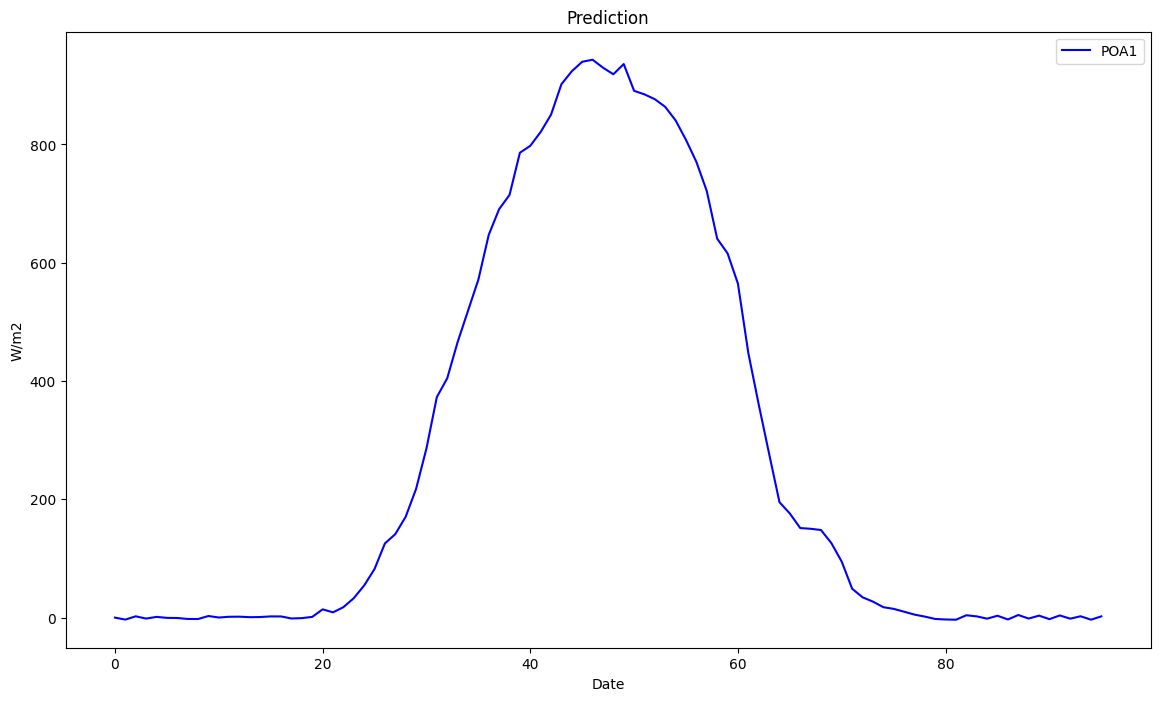

In [16]:
plt.figure(figsize=(14,8))
plt.plot(predict_POA_Rear_p1[:,:,0].reshape(-1,1),label='POA1',color='blue')

plt.title("Prediction")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

POA2

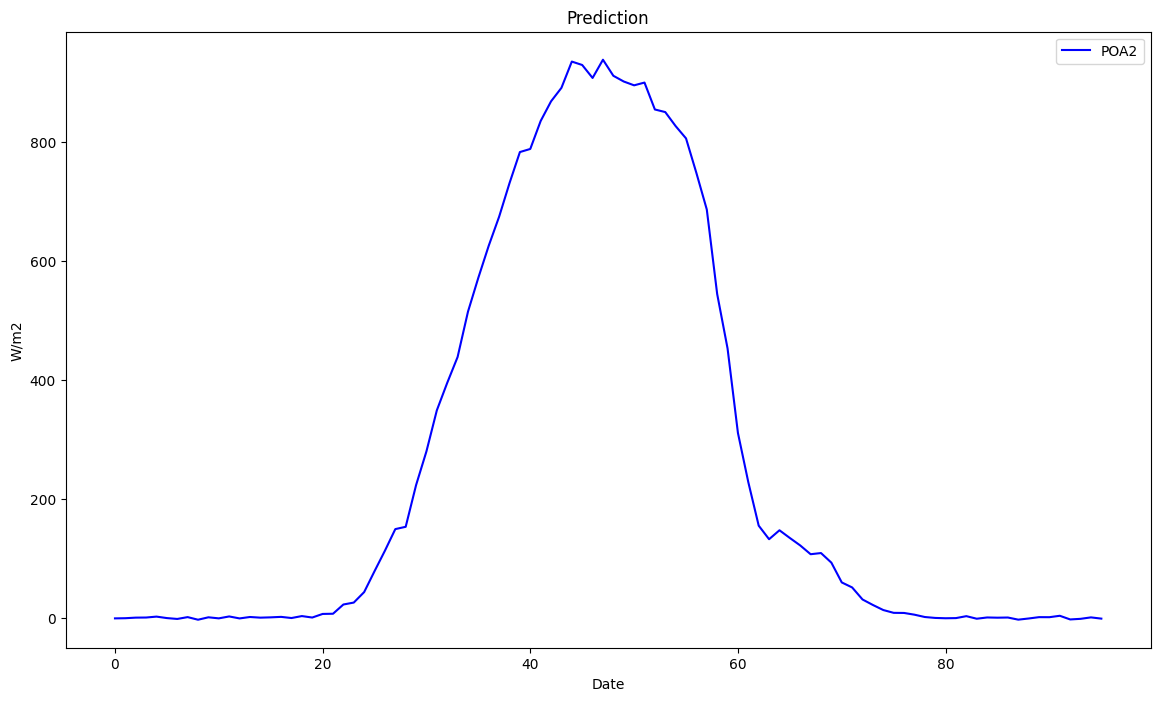

In [17]:
plt.figure(figsize=(14,8))
plt.plot(predict_POA_Rear_p1[:,:,1].reshape(-1,1),label='POA2',color='blue')

plt.title("Prediction")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

Rear1

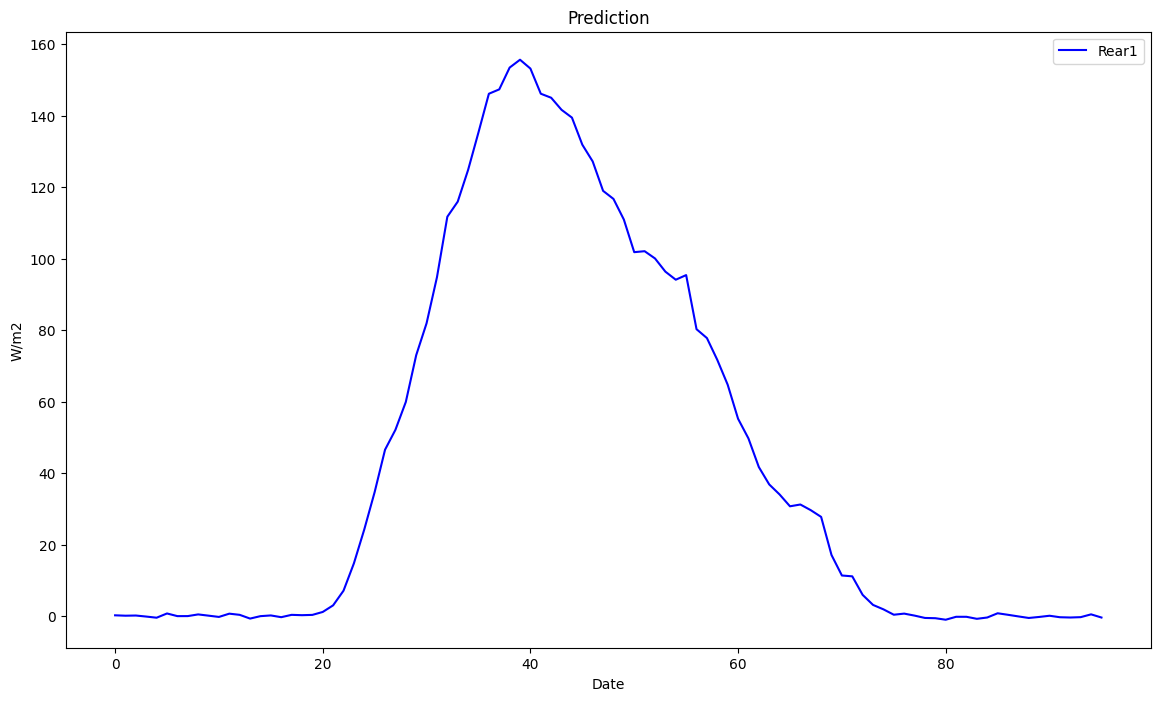

In [18]:
plt.figure(figsize=(14,8))
plt.plot(predict_POA_Rear_p1[:,:,2].reshape(-1,1),label='Rear1',color='blue')

plt.title("Prediction")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

Rear2

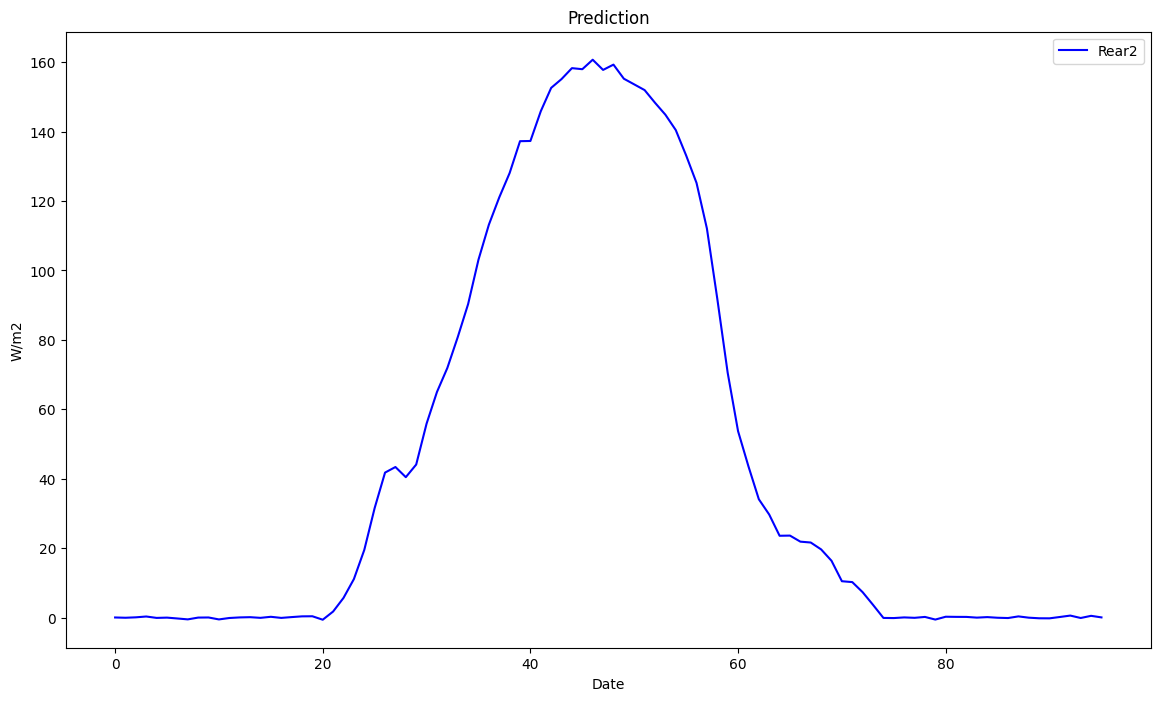

In [19]:
plt.figure(figsize=(14,8))
plt.plot(predict_POA_Rear_p1[:,:,3].reshape(-1,1),label='Rear2',color='blue')

plt.title("Prediction")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()

Rear3

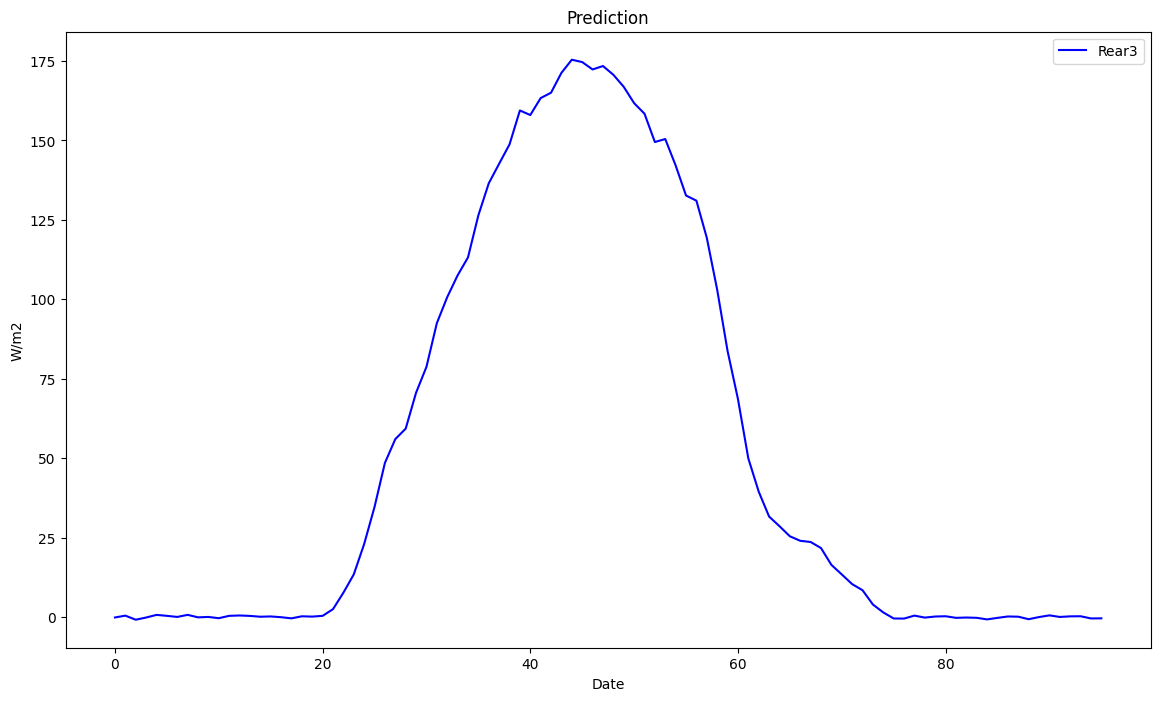

In [20]:
plt.figure(figsize=(14,8))
plt.plot(predict_POA_Rear_p1[:,:,4].reshape(-1,1),label='Rear3',color='blue')

plt.title("Prediction")
plt.xlabel("Date")
plt.ylabel("W/m2")
plt.legend()
plt.show()